# DecodeLabs Data Science Internship
## Project 2: Supervised Learning — Fraud Detection Pipeline

### Objective

The objective of this project is to develop a machine learning pipeline
for identifying potentially fraudulent transactions in an imbalanced
e-commerce dataset.

The project focuses on:

- Handling class imbalance using SMOTE
- Training Logistic Regression and Random Forest classifiers
- Hyperparameter tuning
- Evaluating models using Precision, Recall, and ROC-AUC
- Comparing model performance

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")

## 1. Loading the Dataset

The dataset contains e-commerce transaction records including order,
customer, product, payment, quantity, pricing, and transaction-related
information.

In [3]:
# Load the dataset

df = pd.read_excel("Dataset for Data Analytics.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
# Display Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [5]:
# Check missing values & duplicate records

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows: ", df.duplicated().sum())

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Duplicate Rows:  0


In [6]:
# Diplay column names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


## 2. Exploratory Data Analysis

Before building the classification pipeline, the dataset is examined to
understand its structure, distributions, missing values, and transaction
characteristics.

In [7]:
# Statistical summary of numerical features

df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1200,2024-03-22 16:58:48,2023-01-01 00:00:00,2023-08-03 18:00:00,2024-03-23 00:00:00,2024-11-08 12:00:00,2025-06-30 00:00:00,NaN
Quantity,1200.0,2.945833,1.0,2.0,3.0,4.0,5.0,1.407557
UnitPrice,1200.0,356.41275,11.39,186.0625,364.21,521.57,699.93,197.177146
ItemsInCart,1200.0,5.485,1.0,4.0,5.0,7.0,10.0,2.281983
TotalPrice,1200.0,1053.9683,11.39,410.52,823.615,1578.475,3456.4,819.856558


In [8]:
# Distribution of order statuses

print(df["OrderStatus"].value_counts())

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


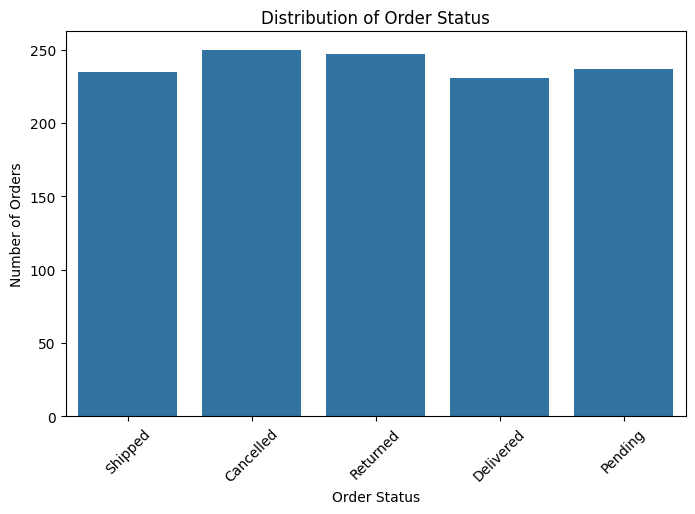

In [9]:
# Visualize order status distribution

plt.figure(figsize = (8, 5))
sns.countplot(data = df, x = "OrderStatus")

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation = 45)

plt.show()

In [10]:
# Distribution of payment methods

print(df["PaymentMethod"].value_counts())

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


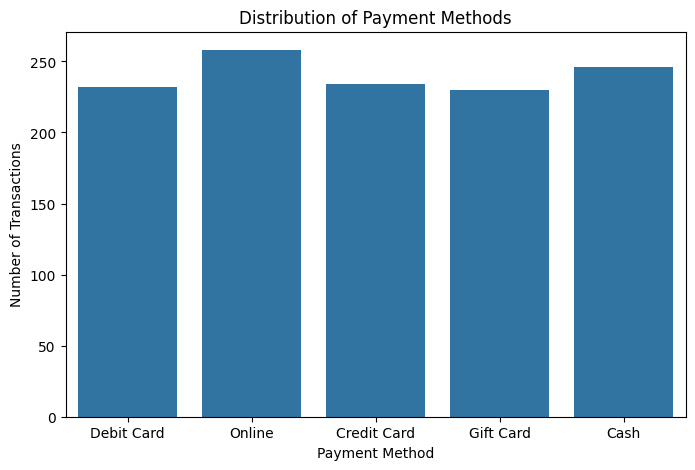

In [11]:
plt.figure(figsize = (8, 5))
sns.countplot(data = df, x = "PaymentMethod")

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

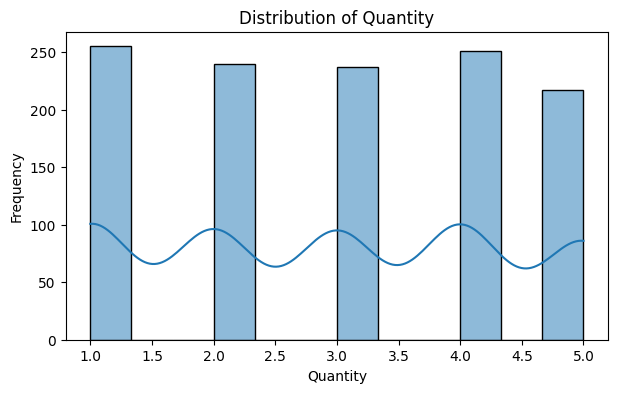

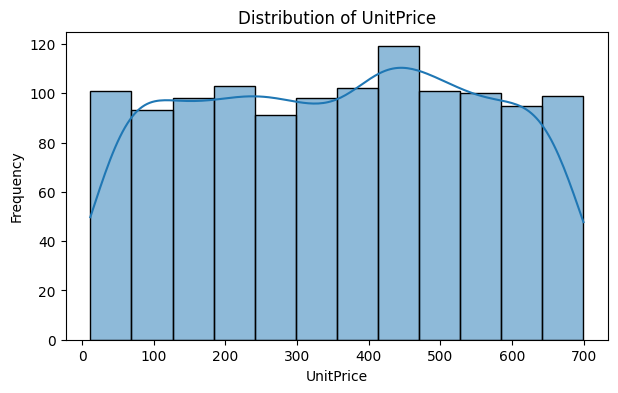

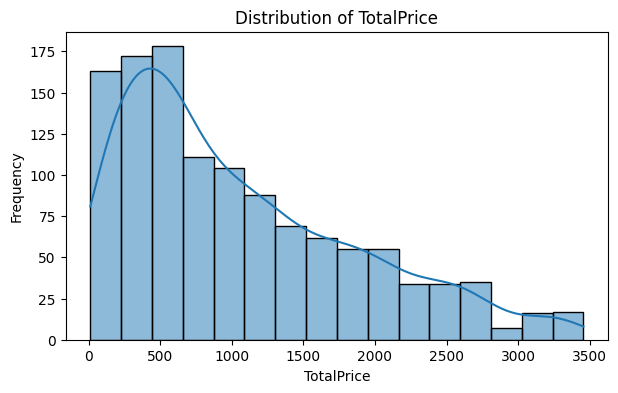

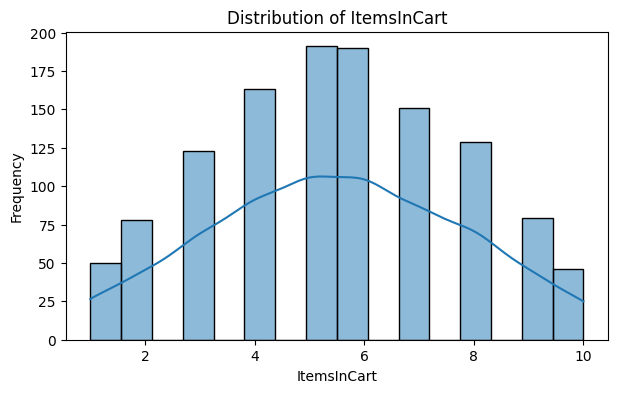

In [12]:
# Distribution of important numerical transaction features

numerical_features = [
    "Quantity",
    "UnitPrice",
    "TotalPrice",
    "ItemsInCart"
]

for feature in numerical_features:
    plt.figure(figsize = (7, 4))
    sns.histplot(data = df, x=feature, kde = True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

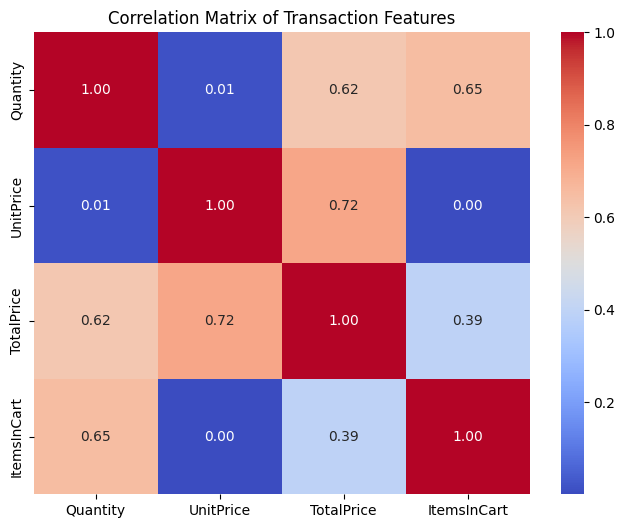

In [13]:
# Correlation between numerical transaction features

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numerical_features].corr(),
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

plt.title("Correlation Matrix of Transaction Features")
plt.show()

### Initial Observations

The exploratory analysis helps identify transaction characteristics that
may be useful for fraud-risk detection. Since the supplied dataset does
not contain a verified fraud indicator, suspicious transaction patterns
will be used to construct a transparent fraud-risk label for the
supervised-learning demonstration.

## 3. Fraud Risk Label Engineering

The dataset does not contain a verified fraud indicator. Therefore, a
rule-based fraud-risk label is engineered using transaction characteristics.

Four numerical characteristics are considered:

- UnitPrice
- TotalPrice
- Quantity
- ItemsInCart

Transactions that exhibit unusually high values across multiple
characteristics receive higher fraud-risk scores.

A transaction is classified as potentially fraudulent when it reaches
at least 3 risk points.

This engineered label is used only to demonstrate the supervised
classification workflow and should not be interpreted as ground-truth
fraud confirmation.

In [14]:
# Calculate thresholds for unusually high transaction values

features_for_risk = [
    "UnitPrice",
    "TotalPrice",
    "Quantity",
    "ItemsInCart"
]

risk_thresholds = df[features_for_risk].quantile(0.75)

print("Fraud Risk Thresholds:")
print(risk_thresholds)

Fraud Risk Thresholds:
UnitPrice       521.570
TotalPrice     1578.475
Quantity          4.000
ItemsInCart       7.000
Name: 0.75, dtype: float64


In [15]:
# Create fraud risk score

df["FraudRiskScore"] = 0

for feature in features_for_risk:
    df["FraudRiskScore"] += (
        df[feature] > risk_thresholds[feature]
    ).astype(int)

df[["OrderID"] + features_for_risk + ["FraudRiskScore"]].head(10)

,OrderID,UnitPrice,TotalPrice,Quantity,ItemsInCart,FraudRiskScore
0,ORD200000,570.62,2853.10,5,7,3
1,ORD200001,151.35,302.70,2,3,0
2,ORD200002,550.68,2753.40,5,8,4
3,ORD200003,273.19,273.19,1,5,0
4,ORD200004,626.01,2504.04,4,8,3
5,ORD200005,245.86,491.72,2,4,0
6,ORD200006,664.42,664.42,1,6,1
7,ORD200007,149.55,747.75,5,9,2
8,ORD200008,134.28,268.56,2,2,0
9,ORD200009,509.38,2037.52,4,6,1


In [16]:
# Create binary fraud-risk target

df["FraudFlag"] = (df["FraudRiskScore"] >= 3).astype(int)

print("Fraud Risk Distribution:")
print(df["FraudFlag"].value_counts())

Fraud Risk Distribution:
FraudFlag
0    1076
1     124
Name: count, dtype: int64


In [17]:
print("\nFraud Risk Percentages:")
print(df["FraudFlag"].value_counts(normalize = True) * 100)


Fraud Risk Percentages:
FraudFlag
0    89.666667
1    10.333333
Name: proportion, dtype: float64


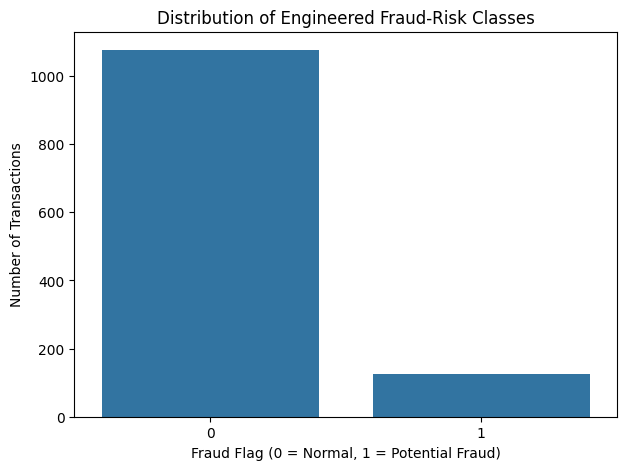

In [18]:
plt.figure(figsize = (7, 5))

sns.countplot(data = df, x = "FraudFlag")

plt.title("Distribution of Engineered Fraud-Risk Classes")
plt.xlabel("Fraud Flag (0 = Normal, 1 = Potential Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

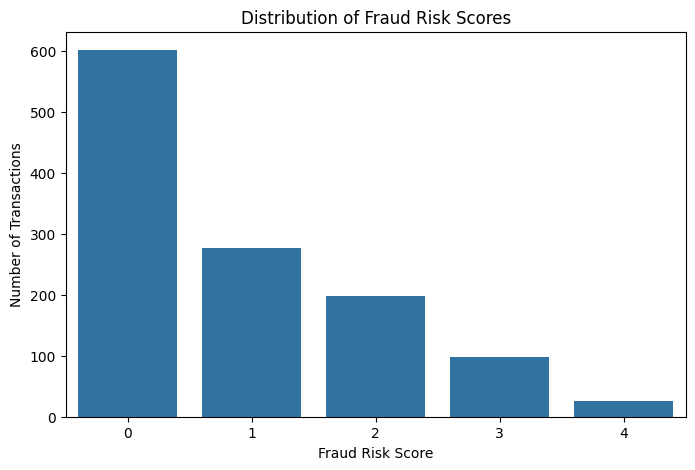

In [19]:
plt.figure(figsize = (8, 5))

sns.countplot(data = df, x = "FraudRiskScore")

plt.title("Distribution of Fraud Risk Scores")
plt.xlabel("Fraud Risk Score")
plt.ylabel("Number of Transactions")

plt.show()

## 4. Feature and Target Preparation

The engineered `FraudFlag` is used as the target variable.

Identifier fields and direct transaction identifiers are excluded because
they do not provide meaningful predictive information for fraud-risk
classification.

The remaining transaction attributes are divided into numerical and
categorical features for preprocessing.

In [20]:
# Separate features and target

target = "FraudFlag"

X = df.drop(columns=["FraudFlag", "FraudRiskScore"])
y = df[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1200, 14)
Target Shape: (1200,)


In [21]:
# Remove identifier and non-predictive columns

columns_to_drop = [
    "OrderID",
    "CustomerID",
    "TrackingNumber",
    "Date",
    "ShippingAddress"
]

X = X.drop(columns=columns_to_drop)

print("Remaining Features:")
print(X.columns.tolist())

Remaining Features:
['Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'OrderStatus', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [22]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include = ["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include = ["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Categorical Features:
['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']


In [23]:
# Check the final feature dataset

X.head()

,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,Monitor,5,570.62,Debit Card,Shipped,7,SAVE10,Instagram,2853.10
1,Phone,2,151.35,Online,Shipped,3,SAVE10,Referral,302.70
2,Tablet,5,550.68,Credit Card,Cancelled,8,FREESHIP,Email,2753.40
3,Chair,1,273.19,Debit Card,Returned,5,SAVE10,Facebook,273.19
4,Printer,4,626.01,Online,Delivered,8,SAVE10,Email,2504.04


In [24]:
# Confirm target distribution

print("Target Distribution:")
print(y.value_counts())

print("\nTarget Percentages:")
print((y.value_counts(normalize = True) * 100).round(2))

Target Distribution:
FraudFlag
0    1076
1     124
Name: count, dtype: int64

Target Percentages:
FraudFlag
0    89.67
1    10.33
Name: proportion, dtype: float64


In [25]:
X.head()

,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,Monitor,5,570.62,Debit Card,Shipped,7,SAVE10,Instagram,2853.10
1,Phone,2,151.35,Online,Shipped,3,SAVE10,Referral,302.70
2,Tablet,5,550.68,Credit Card,Cancelled,8,FREESHIP,Email,2753.40
3,Chair,1,273.19,Debit Card,Returned,5,SAVE10,Facebook,273.19
4,Printer,4,626.01,Online,Delivered,8,SAVE10,Email,2504.04


In [26]:
print("Target Distribution:")
print(y.value_counts())

print("\nTarget Percentages:")
print(y.value_counts(normalize=True) * 100)

Target Distribution:
FraudFlag
0    1076
1     124
Name: count, dtype: int64

Target Percentages:
FraudFlag
0    89.666667
1    10.333333
Name: proportion, dtype: float64


## 5. Train-Test Split

The dataset is divided into training and testing sets to evaluate how well the models generalize to unseen data.

A stratified split is used to preserve the proportion of the two target classes in both sets.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Set Shape: (960, 9)
Testing Set Shape: (240, 9)

Training Target Distribution:
FraudFlag
0    861
1     99
Name: count, dtype: int64

Testing Target Distribution:
FraudFlag
0    215
1     25
Name: count, dtype: int64


## 6. Data Preprocessing

Numerical features are standardized using StandardScaler, while categorical features are converted into numerical form using OneHotEncoder.

A ColumnTransformer is used to apply the appropriate preprocessing to each feature type.

In [28]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown = "ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 7. Handling Class Imbalance with SMOTE

The training dataset contains significantly fewer potential fraud cases than normal transactions. SMOTE (Synthetic Minority Over-sampling Technique) is applied only to the training data to balance the classes.

Applying SMOTE only after the train-test split prevents data leakage into the test set.

In [29]:
smote = SMOTE(random_state = 42)

print("Before SMOTE:")
print(y_train.value_counts())

X_train_resampled, y_train_resampled = smote.fit_resample(
    preprocessor.fit_transform(X_train),
    y_train
)

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
FraudFlag
0    861
1     99
Name: count, dtype: int64

After SMOTE:
FraudFlag
0    861
1    861
Name: count, dtype: int64


## 8. Logistic Regression

Logistic Regression is used as the first classification model to establish a baseline for fraud-risk classification.

The model is trained on the SMOTE-balanced training data and evaluated on the original, unseen test data using Precision, Recall, and ROC-AUC.

In [30]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [31]:
y_pred_lr = logistic_model.predict(
    preprocessor.transform(X_test)
)

y_prob_lr = logistic_model.predict_proba(
    preprocessor.transform(X_test)
)[:, 1]

precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("----------------------------")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"ROC-AUC:   {roc_auc_lr:.4f}")

Logistic Regression Results
----------------------------
Precision: 0.6486
Recall:    0.9600
ROC-AUC:   0.9851


In [32]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:
[[202  13]
 [  1  24]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       215
           1       0.65      0.96      0.77        25

    accuracy                           0.94       240
   macro avg       0.82      0.95      0.87       240
weighted avg       0.96      0.94      0.95       240



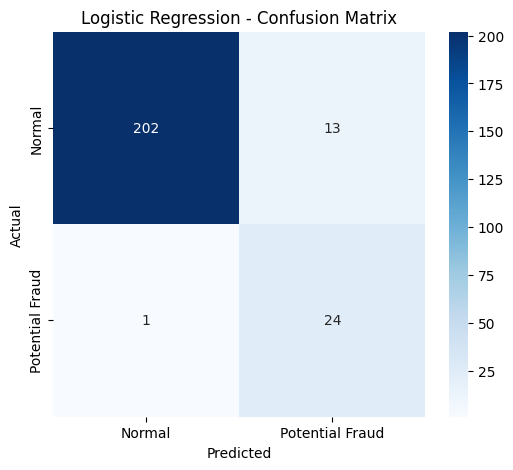

In [33]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Potential Fraud"],
    yticklabels=["Normal", "Potential Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## 9. Random Forest Classifier

Random Forest is used as the second classification model. It combines multiple decision trees to capture nonlinear relationships between transaction features and the engineered fraud-risk target.

The model is trained on the SMOTE-balanced training data and evaluated using Precision, Recall, and ROC-AUC.

In [34]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train_resampled,
    y_train_resampled
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [35]:
y_pred_rf = random_forest.predict(
    preprocessor.transform(X_test)
)

y_prob_rf = random_forest.predict_proba(
    preprocessor.transform(X_test)
)[:, 1]

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

Random Forest Results
---------------------
Precision: 1.0000
Recall:    0.9200
ROC-AUC:   0.9993


In [36]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[215   0]
 [  2  23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       215
           1       1.00      0.92      0.96        25

    accuracy                           0.99       240
   macro avg       1.00      0.96      0.98       240
weighted avg       0.99      0.99      0.99       240



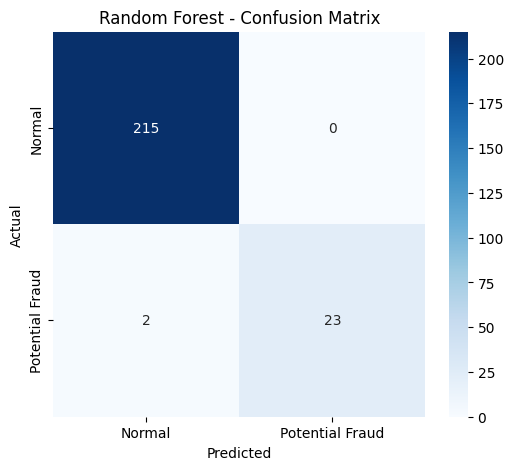

In [37]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Potential Fraud"],
    yticklabels=["Normal", "Potential Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

## 10. Hyperparameter Tuning

Hyperparameter tuning is performed on the Random Forest model to identify a combination of parameters that provides strong classification performance.

RandomizedSearchCV is used with cross-validation, and ROC-AUC is used as the scoring metric because the dataset is imbalanced.

In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_tuning = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_tuning.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(rf_tuning.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(f"{rf_tuning.best_score_:.4f}")

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

Best Cross-Validation ROC-AUC:
0.9999


In [39]:
# Get the best tuned Random Forest model

best_rf = rf_tuning.best_estimator_

# Make predictions on the untouched test set
y_pred_tuned_rf = best_rf.predict(
    preprocessor.transform(X_test)
)

y_prob_tuned_rf = best_rf.predict_proba(
    preprocessor.transform(X_test)
)[:, 1]

# Calculate evaluation metrics
precision_tuned_rf = precision_score(
    y_test,
    y_pred_tuned_rf
)

recall_tuned_rf = recall_score(
    y_test,
    y_pred_tuned_rf
)

roc_auc_tuned_rf = roc_auc_score(
    y_test,
    y_prob_tuned_rf
)

print("Tuned Random Forest Results")
print("---------------------------")
print(f"Precision: {precision_tuned_rf:.4f}")
print(f"Recall:    {recall_tuned_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_tuned_rf:.4f}")

Tuned Random Forest Results
---------------------------
Precision: 1.0000
Recall:    0.9600
ROC-AUC:   0.9998


In [40]:
# Confusion matrix for tuned Random Forest

cm_tuned_rf = confusion_matrix(
    y_test,
    y_pred_tuned_rf
)

print("Confusion Matrix:")
print(cm_tuned_rf)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned_rf
    )
)

Confusion Matrix:
[[215   0]
 [  1  24]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       215
           1       1.00      0.96      0.98        25

    accuracy                           1.00       240
   macro avg       1.00      0.98      0.99       240
weighted avg       1.00      1.00      1.00       240



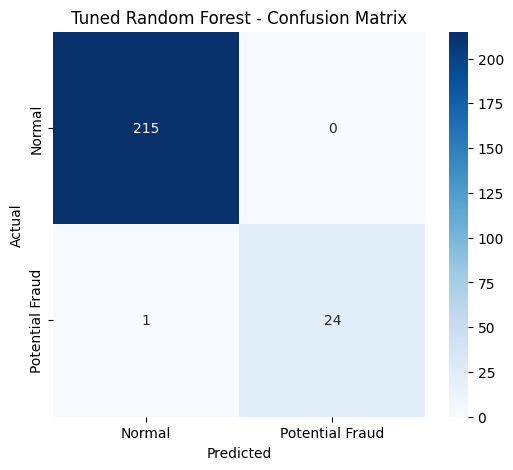

In [41]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Potential Fraud"],
    yticklabels=["Normal", "Potential Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest - Confusion Matrix")

plt.show()

In [42]:
# Compare all models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Precision": [
        precision_lr,
        precision_rf,
        precision_tuned_rf
    ],
    "Recall": [
        recall_lr,
        recall_rf,
        recall_tuned_rf
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_tuned_rf
    ]
})

model_comparison

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.648649,0.96,0.985116
1,Random Forest,1.000000,0.92,0.999349
2,Tuned Random Forest,1.000000,0.96,0.999814


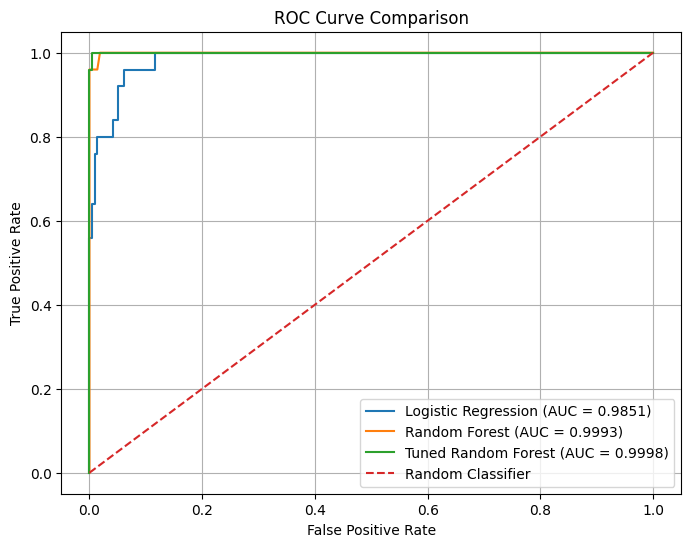

In [43]:
from sklearn.metrics import roc_curve

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_tuned_rf, tpr_tuned_rf, _ = roc_curve(y_test, y_prob_tuned_rf)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.4f})")
plt.plot(fpr_tuned_rf, tpr_tuned_rf, label=f"Tuned Random Forest (AUC = {roc_auc_tuned_rf:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

### ROC Curve Interpretation

The ROC curve compares the classification performance of the three models across different classification thresholds.

Logistic Regression achieved a ROC-AUC of 0.9851, indicating strong classification performance. Random Forest performed better with a ROC-AUC of 0.9993, while the Tuned Random Forest achieved the highest ROC-AUC of 0.9998.

The ROC curves of the Random Forest models are very close to the top-left corner, indicating a strong ability to distinguish between the two classes with a low false-positive rate. Therefore, the Tuned
Random Forest is selected as the final model based on its highest ROC-AUC, along with its strong precision and recall.

## Final Model Selection

Based on the evaluation results, the **Tuned Random Forest** was selected as the final model.

It achieved:
- Precision: **1.0000**
- Recall: **0.9600**
- ROC-AUC: **0.9998**

The model correctly identified 24 out of 25 potential fraud cases in the test set, with only 1 false negative and no false positives. Compared with the default Random Forest, hyperparameter tuning improved recall from **0.9200 to 0.9600** while maintaining a precision of **1.0000**.

Therefore, the Tuned Random Forest provided the best overall balance of precision, recall, and ROC-AUC among the tested models.

## Conclusion

This project developed a fraud-risk classification pipeline using an e-commerce transaction dataset. The dataset was explored through descriptive statistics, distribution analysis, and correlation analysis before preparing the features for machine learning.

Since the original dataset did not contain an explicit fraud label, a **FraudFlag** was engineered using a risk-scoring approach based on transaction-related numerical features. The resulting target variable was imbalanced, with potential fraud cases representing a smaller portion of the dataset.

To address class imbalance, **SMOTE (Synthetic Minority Over-sampling Technique)** was applied to the training data. Logistic Regression, Random Forest, and a hyperparameter-tuned Random Forest were then trained and evaluated using Precision, Recall, and ROC-AUC.

The **Tuned Random Forest** performed best, achieving a Precision of **1.0000**, Recall of **0.9600**, and ROC-AUC of **0.9998** on the test set. These results indicate that the model performed very well at distinguishing the two classes under the engineered fraud-risk definition.

Overall, the project demonstrates the complete machine learning workflow of data exploration, feature preparation, handling class imbalance, model training, hyperparameter tuning, and performance evaluation.

## Limitations

The most important limitation of this project is that the dataset did not provide a verified real-world fraud label. Instead, the target variable was engineered using transaction features such as UnitPrice, TotalPrice, Quantity and ItemsInCart.

Because these same features were available to the models, the very high performance scores may partly reflect the relationship between the engineered target and its input features. Therefore, the reported ROC-AUC of 0.9998 should not be interpreted as evidence that the model can detect real-world fraud with 99.98% performance.

For a production fraud-detection system, a dataset containing verified historical fraud and legitimate transactions would be required. Future work could also include additional behavioral, payment, and transaction-level features and evaluate the model on new unseen real-world transactions.